# SMS Spam Classifier - Exploratory Data Analysis

## Objective

The objective of this notebook is to understand the SMS Spam Collection dataset before building a Machine Learning model.

### Steps Covered

- Import libraries
- Load dataset
- Inspect dataset
- Clean dataset
- Analyze class distribution
- Create new features
- Visualize the data
- Draw conclusions

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

In [24]:
df = pd.read_csv("../dataset/spam.csv", encoding="latin-1")

In [25]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [26]:
df.shape

(5572, 5)

In [27]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [29]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [30]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

In [31]:
df = df.rename(columns={
    "v1": "target",
    "v2": "text"
})

In [32]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [33]:
df.duplicated().sum()

np.int64(403)

In [34]:
df = df.drop_duplicates(keep="first")

In [35]:
df.shape

(5169, 2)

## Data Cleaning Summary

The following preprocessing steps were performed:

- Removed unnecessary columns (`Unnamed: 2`, `Unnamed: 3`, `Unnamed: 4`)
- Renamed columns:
  - `v1` → `target`
  - `v2` → `text`
- Removed duplicate records

Dataset Shape

- Before Cleaning: **5572 × 5**
- After Cleaning: **5169 × 2**

In [36]:
df["target"].value_counts()

target
ham     4516
spam     653
Name: count, dtype: int64

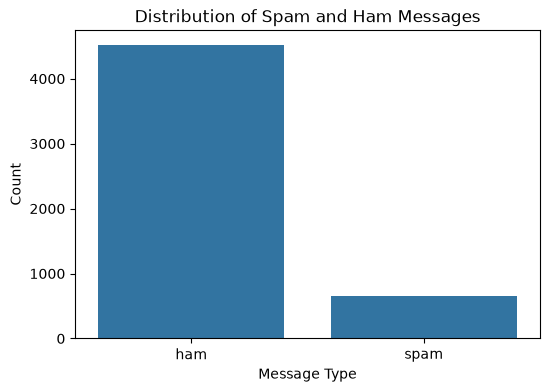

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["target"])

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

### Observation

The dataset is imbalanced.

Most of the messages belong to the **Ham** class, while **Spam** messages are significantly fewer.

This imbalance should be considered while evaluating the Machine Learning model because accuracy alone may be misleading.

## Feature Engineering

In [38]:
import nltk

In [39]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Payal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [40]:
df["num_characters"] = df["text"].apply(len)

In [41]:
df.head()

,target,text,num_characters
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


## Word Count Feature

In [42]:
df["num_words"] = df["text"].apply(lambda x: len(nltk.word_tokenize(x)))

## Sentence Count Feature

In [43]:
df["num_sentences"] = df["text"].apply(lambda x: len(nltk.sent_tokenize(x)))

In [44]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [45]:
df.describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


## Character Count Analysis

In [46]:
df.groupby("target")["num_characters"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
ham,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
spam,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


In [47]:
df.groupby("target")["num_words"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
ham,4516.0,17.123782,13.493970,1.0,8.0,13.0,22.0,220.0
spam,653.0,27.667688,7.008418,2.0,25.0,29.0,32.0,46.0


In [48]:
df.groupby("target")["num_sentences"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
ham,4516.0,1.820195,1.383657,1.0,1.0,1.0,2.0,38.0
spam,653.0,2.970904,1.488425,1.0,2.0,3.0,4.0,9.0


## Character Distribution

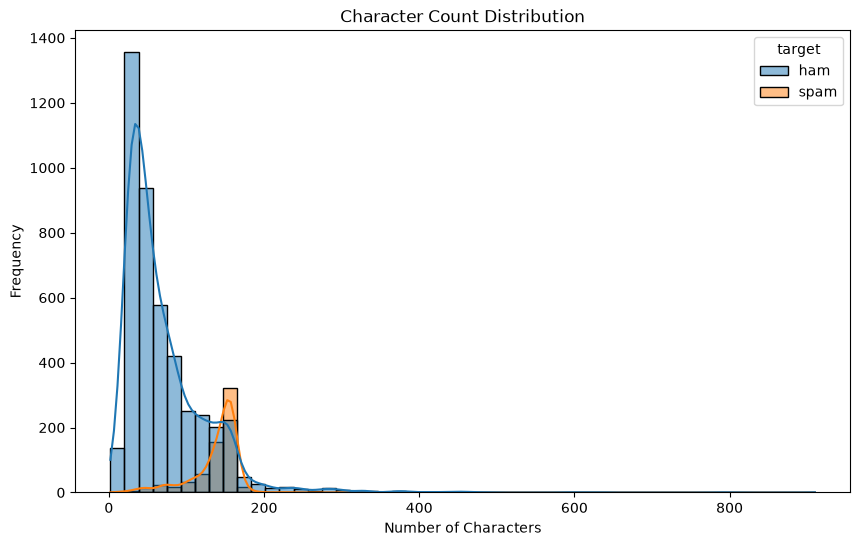

In [49]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="num_characters",
    hue="target",
    bins=50,
    kde=True
)

plt.title("Character Count Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

### Observation

The character count distribution shows that spam messages are generally longer than ham messages.

Most ham messages contain fewer than 100 characters, whereas spam messages are concentrated around 120–170 characters.

Although there is some overlap between the two classes, message length appears to be a useful feature for spam detection.

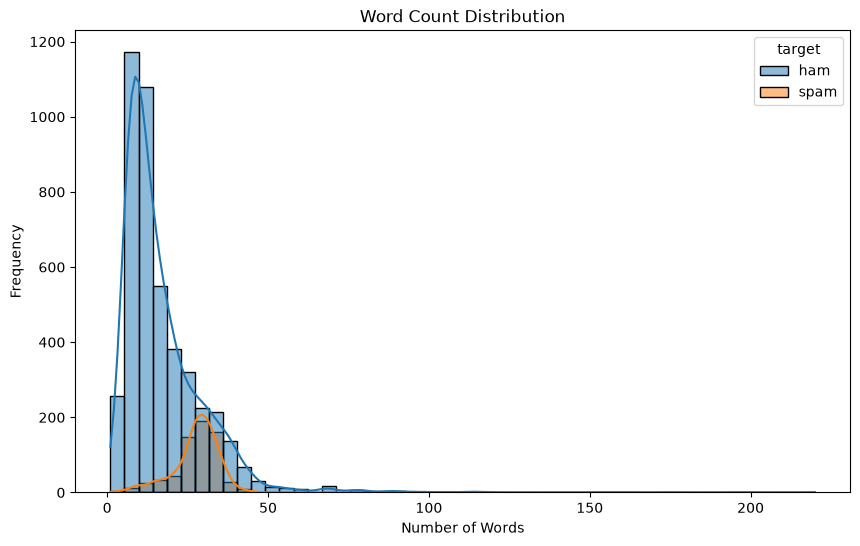

In [50]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="num_words",
    hue="target",
    bins=50,
    kde=True
)

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

### Observation

Spam messages generally contain more words than ham messages.

Most ham messages are short and contain fewer than 20 words, whereas spam messages tend to contain between 20 and 35 words.

The distribution indicates that the number of words can serve as a useful feature for spam classification.

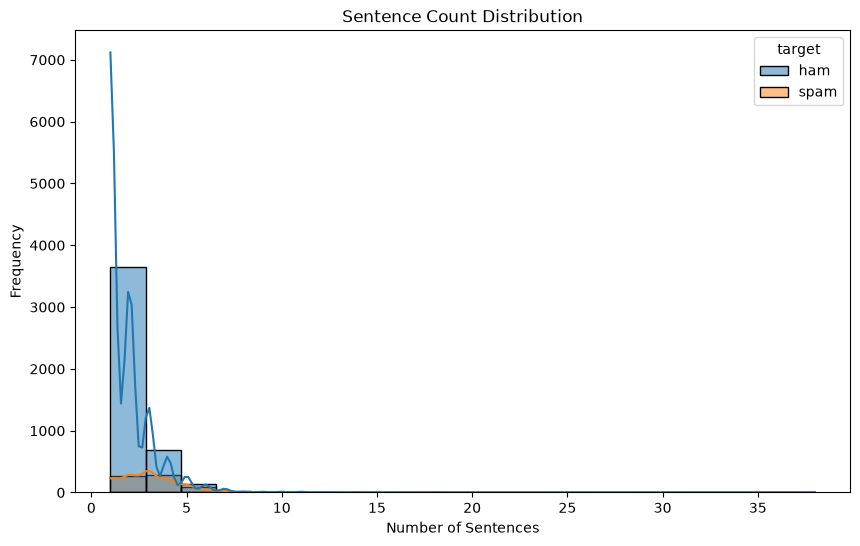

In [51]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="num_sentences",
    hue="target",
    bins=20,
    kde=True
)

plt.title("Sentence Count Distribution")
plt.xlabel("Number of Sentences")
plt.ylabel("Frequency")

plt.show()

### Observation

Spam messages usually contain more sentences than ham messages.

However, the overlap between the two classes is larger compared to character and word counts.

Therefore, sentence count may contribute to prediction but is expected to be less informative than character count or word count.

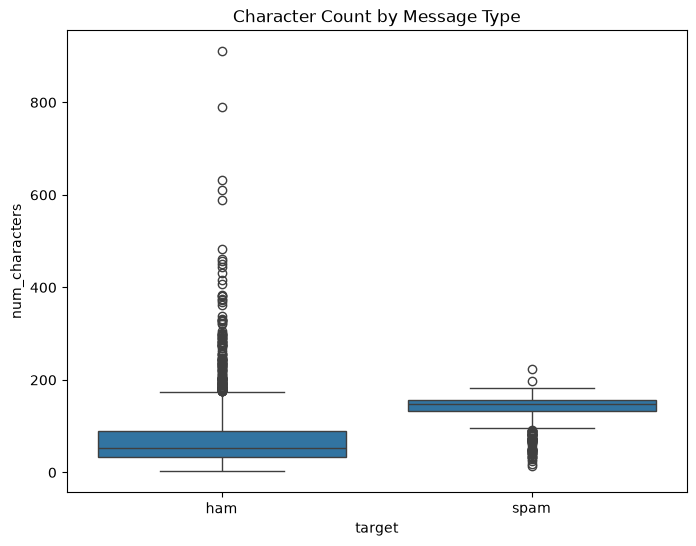

In [52]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="target",
    y="num_characters"
)

plt.title("Character Count by Message Type")

plt.show()

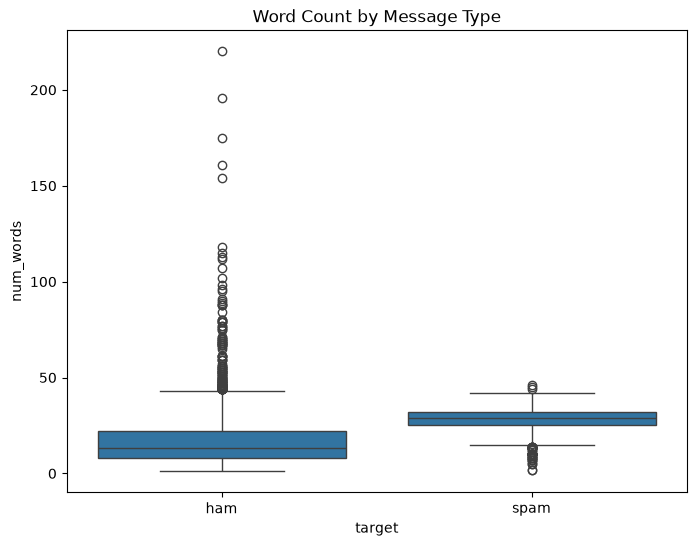

In [53]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="target",
    y="num_words"
)

plt.title("Word Count by Message Type")

plt.show()

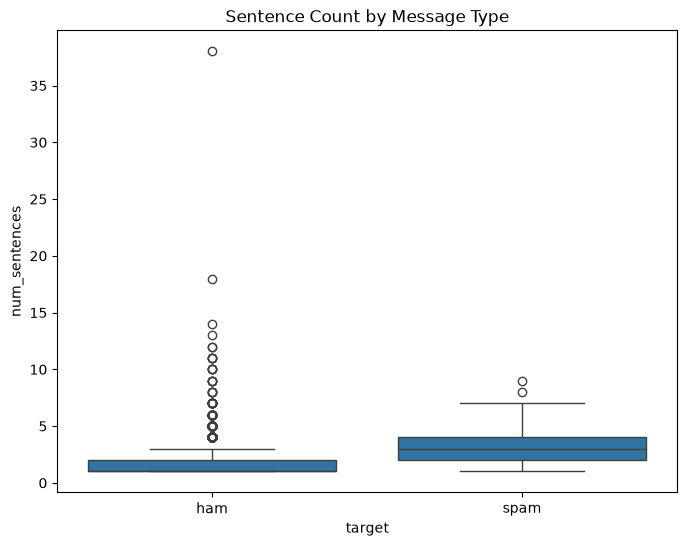

In [54]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="target",
    y="num_sentences"
)

plt.title("Sentence Count by Message Type")

plt.show()

### Observation

The boxplots confirm that spam messages generally have higher character counts, word counts, and sentence counts than ham messages.

Several outliers are also visible, especially among ham messages, indicating that a few legitimate messages can also be quite long.

Overall, these numerical features provide useful information for distinguishing spam from ham.

In [55]:
df["target_num"] = df["target"].map({
    "ham":0,
    "spam":1
})

In [56]:
df.head()

,target,text,num_characters,num_words,num_sentences,target_num
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2,0
1,ham,Ok lar... Joking wif u oni...,29,8,2,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,1
3,ham,U dun say so early hor... U c already then say...,49,13,1,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1,0


In [57]:
df.corr(numeric_only=True)

,num_characters,num_words,num_sentences,target_num
num_characters,1.000000,0.965760,0.624139,0.384717
num_words,0.965760,1.000000,0.679971,0.262912
num_sentences,0.624139,0.679971,1.000000,0.263939
target_num,0.384717,0.262912,0.263939,1.000000


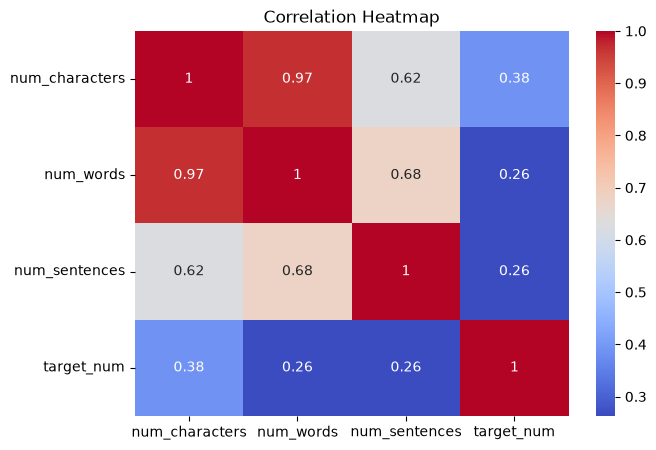

In [58]:
plt.figure(figsize=(7,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows that the numerical features are positively correlated with each other.

The target variable also has a positive correlation with character count, word count, and sentence count, indicating that longer messages are more likely to be spam.

Among these features, character count and word count exhibit the strongest relationship with the target.

# Conclusion

The exploratory analysis revealed several important insights:

- The dataset contains more ham messages than spam messages.
- Spam messages are generally longer in terms of characters, words, and sentences.
- Character count and word count show a stronger relationship with the target variable.
- The engineered text-length features are expected to improve spam classification performance.

The cleaned dataset is now ready for text preprocessing, vectorization using TF-IDF, and machine learning model training.